# Esercitazione_1

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import binom,poisson

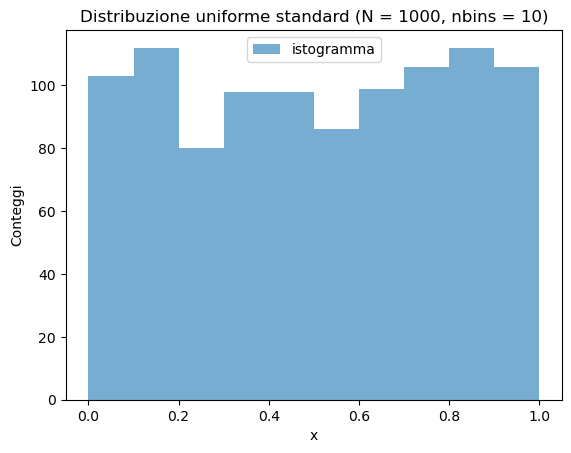

In [11]:
N=1000
data=np.random.uniform(0,1,N)

#vedi documentazione https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
nbins=10
h, bordi, patches = plt.hist(data, bins=nbins, range=(0,1), alpha=0.6, label='istogramma')

#calcolo la larghezza di un bin
delta_x = bordi[1] - bordi[0]
centri = (bordi[:-1] + bordi[1:]) / 2

plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione uniforme standard (N = {N}, nbins = {nbins})")
plt.legend()
plt.show()


In [12]:
#dato che è una distribuzione uniforme, allora la probabilità è data da 1/(b-a) dove a=0 e b=1
f_prob= 1/(1-0)
p= f_prob * delta_x

print(f"probabilità per bin: {p}")

probabilità per bin: 0.1


In [13]:
# posso vedere il fatto che un dato cada all'interno di un bin come una distribuzione di Bernulli, di cui so che il valore di aspettazione è N*p, mentre la varianza è N*p*(1-p)
E_bin= N*p
var_bin=N*p*(1-p)
sigma_bin= math.sqrt(var_bin)

list_1=[E_bin]*len(centri)


print(f"valore di aspettazione per bin: {E_bin}")
print(f"varianza per bin: {var_bin}") 
print(f"sigma per bin: {sigma_bin}")  

valore di aspettazione per bin: 100.0
varianza per bin: 90.0
sigma per bin: 9.486832980505138


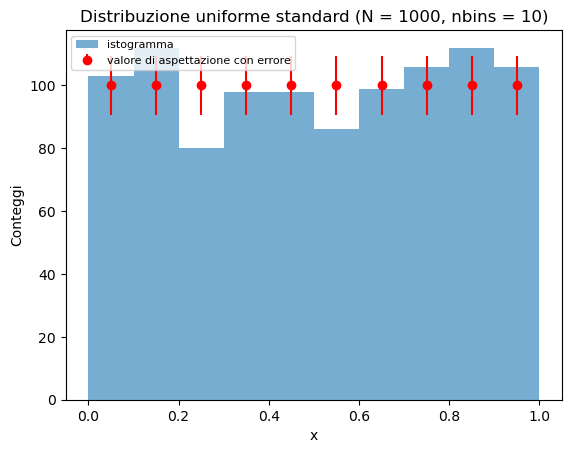

In [14]:
h, bordi, patches = plt.hist(data, bins=nbins, range=(0,1), alpha=0.6, label='istogramma')

plt.errorbar(centri, list_1, yerr=sigma_bin, fmt='o', color='red', label='valore di aspettazione con errore')

plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione uniforme standard (N = {N}, nbins = {nbins})")
plt.legend(loc='best', prop={'size': 8})
plt.show()

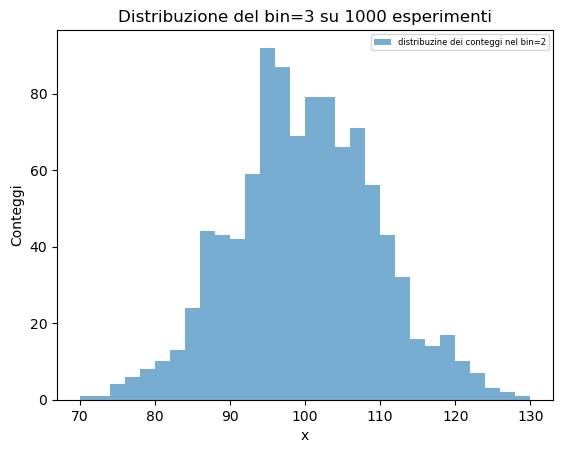

In [15]:
list_2=[]

M=1000

for i in range(M):
    data=np.random.uniform(0,1,N)
    h_1, bordi_1 = np.histogram(data, bins=nbins, range=(0,1))
    list_2.append(h_1)

matr_hist=np.array(list_2)

n_bins1=30
a=3
h_2, bordi_2, patches_2 = plt.hist(matr_hist[:,a], bins=n_bins1, range=(70,130), alpha=0.6, label='distribuzine dei conteggi nel bin=2')

plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione del bin={a} su 1000 esperimenti")
plt.legend(loc='best', prop={'size': 6})
plt.show()

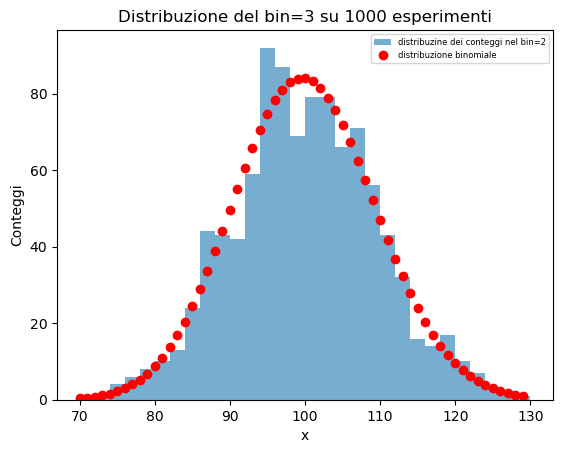

In [16]:
k=range(70,130)
P_bin = binom.pmf(k , N , p )
dk= (130-70)/n_bins1

h_2, bordi_2, patches_2 = plt.hist(matr_hist[:,a], bins=n_bins1, range=(70,130), alpha=0.6, label='distribuzine dei conteggi nel bin=2')
plt.plot(k, P_bin*M*dk, 'o',color='red', label='distribuzione binomiale')

plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione del bin={a} su 1000 esperimenti")
plt.legend(loc='best', prop={'size': 6})
plt.show()

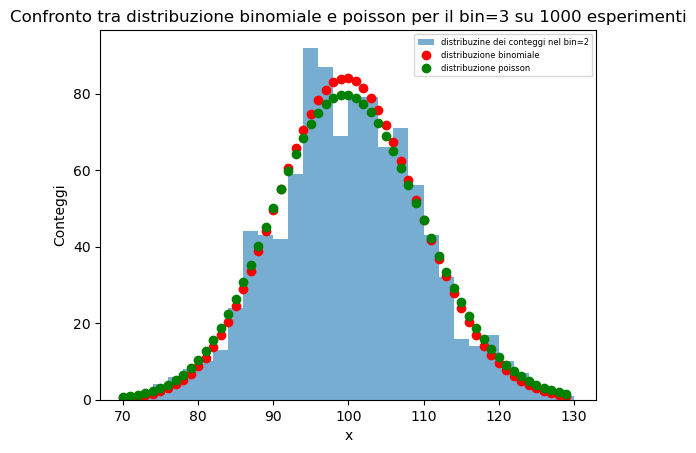

In [17]:
k=range(70,130)
P_bin = binom.pmf(k , N , p )
P_poisson= poisson.pmf(k, N*p)

h_2, bordi_2, patches_2 = plt.hist(matr_hist[:,a], bins=n_bins1, range=(70,130), alpha=0.6, label='distribuzine dei conteggi nel bin=2')
plt.plot(k, P_bin*M*dk, 'o',color='red', label='distribuzione binomiale')
plt.plot(k, P_poisson*M*dk, 'o',color='green', label='distribuzione poisson')  

plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Confronto tra distribuzione binomiale e poisson per il bin={a} su 1000 esperimenti")
plt.legend(loc='best', prop={'size': 6})
plt.show()

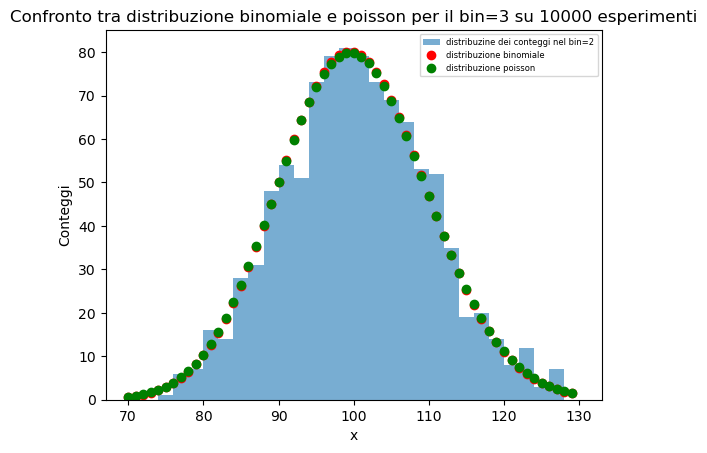

In [18]:
N_1=int(1e4)
n_bins2=int(1e2)
p_1= 0.01
list_3=[]

for i in range(M):
    data=np.random.uniform(0,1,N_1)
    h_3, bordi_3 = np.histogram(data, bins=n_bins2, range=(0,1))
    list_3.append(h_3)

matr_hist1=np.array(list_3)

n_bins1=30
a=3

k=range(70,130)

P_bin1 = binom.pmf(k , N_1 , p_1 )
P_poisson1= poisson.pmf(k, N_1*p_1)

h_2, bordi_2, patches_2 = plt.hist(matr_hist1[:,a], bins=n_bins1, range=(70,130), alpha=0.6, label='distribuzine dei conteggi nel bin=2')
plt.plot(k, P_bin1*M*dk, 'o',color='red', label='distribuzione binomiale')
plt.plot(k, P_poisson1*M*dk, 'o',color='green', label='distribuzione poisson')  

plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Confronto tra distribuzione binomiale e poisson per il bin={a} su 10000 esperimenti")
plt.legend(loc='best', prop={'size': 6})
plt.show()

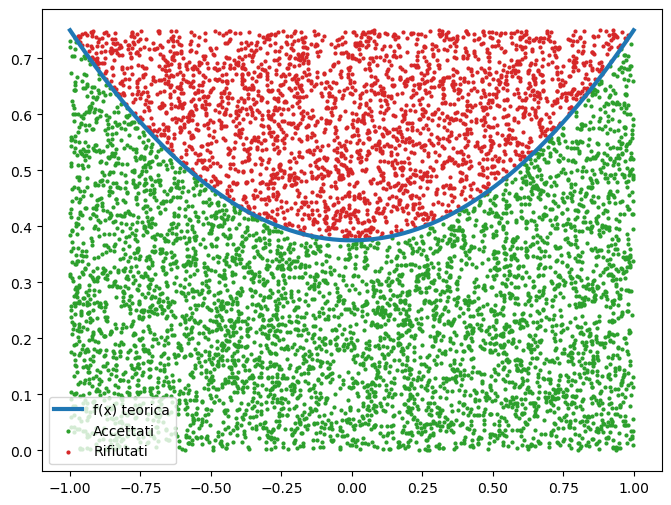

In [19]:
def mia_funz(x):
    return 3/8*(1+x**2)
# Parametri del dominio e numero di punti
xmin, xmax = -1, 1
fmax = 3/4
N = 5000
accepted_x, accepted_y = [], []
rejected_x, rejected_y = [], []
# Ciclo Accept-Reject
while len(accepted_x) < N:
    x = np.random.uniform(xmin, xmax)
    y = np.random.uniform(0, fmax)
    if y <= mia_funz(x):
        accepted_x.append(x)
        accepted_y.append(y)
    else:
        rejected_x.append(x)
        rejected_y.append(y)
# Visualizzazione dei risultati
plt.figure(figsize=(8,6))
x_plot = np.linspace(xmin, xmax, 400)
plt.plot(x_plot, mia_funz(x_plot), label='f(x) teorica', lw=3)
plt.scatter(accepted_x, accepted_y, color='tab:green', s=4, label='Accettati')
plt.scatter(rejected_x, rejected_y, color='tab:red', s=4, label='Rifiutati' )
plt.legend()
plt.show()